In [1]:
import mcstasscript as ms
import mcstastox as mx
import scipp as sc
from scipp.typing import VariableLike
import scipp as sc
from scippneutron.conversion.graph.beamline import beamline
from trex_reduction import inelastic
from trex_reduction import produce_trex_event_object

In [2]:
file_path = "/Users/bb24144/Documents/McStas/let_scipp/mcstas_to_scipp/ISIS_LET_generated_9"

with mx.Read(file_path) as loaded_data:
    scipp_object = loaded_data.export_scipp_simple(source_name="SourceMantid",
                                            sample_name="iso_samp")
    
data = ms.load_data(file_path)

In [3]:
with mx.Read(file_path) as loaded_data:
    print("=== All components ===")
    print(loaded_data.get_components())
    print("=== Components with data ===")
    print(loaded_data.get_components_with_data())
    print("=== Components with IDs ===")
    print(loaded_data.get_components_with_ids()) 
    print("=== Components with geometry ===")
    print(loaded_data.get_components_with_geometry())

=== All components ===
['Origin', 'SourceMantid', 'shutter', 'insert', 'after_insert', 'Monitor1', 'LET_Chopper1_disk1', 'LET_Chopper1_disk2', 'Monitor2', 'between_chop1_and_chop2', 'LET_Chopper2', 'Monitor3', 'between_chop2_and_chop3', 'LET_Chopper3', 'Monitor4', 'between_chop3_and_chop4', 'LET_Chopper4', 'Monitor5', 'between_chop4_and_movable', 'moveable_front_PSDmon', 'moveable_front_Divmon', 'moveable_guide', 'moveable_back_PSDmon', 'moveable_back_Divmon', 'funnel', 'LET_Chopper5_Disk1', 'LET_Chopper5_Disk2', 'Monitor6', 'tanksection', 'snout', 'sample', 'sample_PSDmon', 'sample_Divmon', 'sample_tof', 'sample_Emon', 'iso_samp', 'detectorArm', 'Banana_1']
=== Components with data ===
['Monitor1', 'Monitor2', 'Monitor3', 'Monitor4', 'Monitor5', 'Monitor6', 'sample_PSDmon', 'sample_Divmon', 'sample_tof', 'sample_Emon', 'Banana_1']
=== Components with IDs ===
['Banana_1']
=== Components with geometry ===
['Banana_1']


In [4]:
with mx.Read(file_path) as loaded_data:
    scipp_object = loaded_data.export_scipp_simple(source_name="SourceMantid",
                                            sample_name="iso_samp")
    
# Load event data into scipp 
event_object = scipp_object
# McStas provides absolute time, not time of flight
event_object.coords["tof"] = event_object.coords["t"]
# Add additional information required for inelastic scattering
event_object = produce_trex_event_object(event_object, file_path, "Monitor6")
event_object

<scipp.DataArray>
Dimensions: Sizes[events:47528, ]
Coordinates:
* monitor_position          vector3              [m]  ()  (0, 0, 23.505)
* position                  vector3              [m]  (events)  [(1.68366, -0.528926, 27.483), (2.21463, -0.859504, 27.0237), ..., (1.81074, -0.842975, 27.3919), (2.81867, -0.479339, 26.0272)]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.0333971, 0.0335807, ..., 0.033436, 0.0334332]
* time_on_monitor           float64              [s]  (events)  [0.0280169, 0.0280169, ..., 0.0280169, 0.0280169]
* tof                       float64              [s]  (events)  [0.0333971, 0.0335807, ..., 0.033436, 0.0334332]
Data:
                            float64         [counts]  (events)  [0.0394161, 0.0312343, ..., 0.025033, 0.235707]

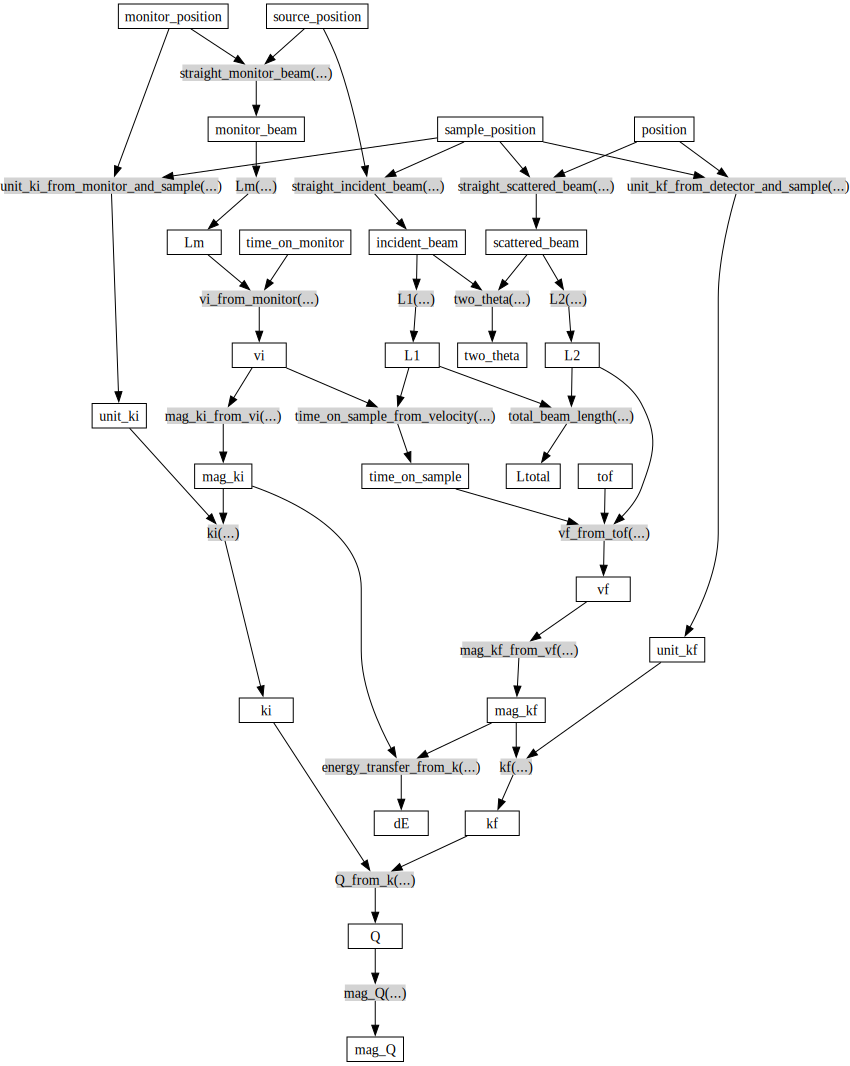

In [5]:
qens_graph = {**beamline(scatter=True), **inelastic}
sc.show_graph(qens_graph)

In [6]:
event_object = event_object.transform_coords("dE", graph=qens_graph)
event_object = event_object.transform_coords("mag_Q", graph=qens_graph)
event_object

<scipp.DataArray>
Dimensions: Sizes[events:47528, ]
Coordinates:
  L1                        float64              [m]  ()  25
  L2                        float64              [m]  (events)  [3.04627, 3.1207, ..., 3.11618, 3.03805]
  Lm                        float64              [m]  ()  23.505
  Q                         vector3            [1/m]  (events)  [(-7.43179e+09, 2.33471e+09, 2.36466e+09), (-9.30072e+09, 3.60963e+09, 4.82584e+09), ..., (-7.90715e+09, 3.68111e+09, 2.87976e+09), (-1.23182e+10, 2.09481e+09, 8.8358e+09)]
* dE                        float64            [meV]  (events)  [-0.0674886, 0.11987, ..., -0.157943, 0.0263627]
  incident_beam             vector3              [m]  ()  (0, 0, 25)
  kf                        vector3            [1/m]  (events)  [(7.43179e+09, -2.33471e+09, 1.09601e+10), (9.30072e+09, -3.60963e+09, 8.49892e+09), ..., (7.90715e+09, -3.68111e+09, 1.0445e+10), (1.23182e+10, -2.09481e+09, 4.48897e+09)]
  ki                        vector3            [1/m]  (events)  [(0, 0, 1.33248e+10), (0, 0, 1.33248e+10), ..., (0, 0, 1.33248e+10), (0, 0, 1.33248e+10)]
* mag_Q                     float64           [1/Å]  (events)  [0.814089, 1.10825, ..., 0.918513, 1.53035]
  mag_kf                    float64            [1/m]  (events)  [1.34464e+10, 1.31059e+10, ..., 1.36078e+10, 1.32769e+10]
  mag_ki                    float64            [1/m]  (events)  [1.33248e+10, 1.33248e+10, ..., 1.33248e+10, 1.33248e+10]
  monitor_beam              vector3              [m]  ()  (0, 0, 23.505)
  monitor_position          vector3              [m]  ()  (0, 0, 23.505)
  position                  vector3              [m]  (events)  [(1.68366, -0.528926, 27.483), (2.21463, -0.859504, 27.0237), ..., (1.81074, -0.842975, 27.3919), (2.81867, -0.479339, 26.0272)]
  sample_position           vector3              [m]  ()  (0, 0, 25)
  scattered_beam            vector3              [m]  (events)  [(1.68366, -0.528926, 2.483), (2.21463, -0.859504, 2.02371), ..., (1.81074, -0.842975, 2.39191), (2.81867, -0.479339, 1.02717)]
  source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.0333971, 0.0335807, ..., 0.033436, 0.0334332]
  time_on_monitor           float64              [s]  (events)  [0.0280169, 0.0280169, ..., 0.0280169, 0.0280169]
  time_on_sample            float64              [s]  (events)  [0.0297989, 0.0297989, ..., 0.0297989, 0.0297989]
  tof                       float64              [s]  (events)  [0.0333971, 0.0335807, ..., 0.033436, 0.0334332]
  unit_kf                   vector3  [dimensionless]  (events)  [(0.552696, -0.173631, 0.815095), (0.709659, -0.275421, 0.648481), ..., (0.581076, -0.270515, 0.767576), (0.927789, -0.157778, 0.338103)]
  unit_ki                   vector3  [dimensionless]  ()  (0, 0, 1)
  vf                        float64            [m/s]  (events)  [846.617, 825.177, ..., 856.776, 835.946]
  vi                        float64            [m/s]  (events)  [838.957, 838.957, ..., 838.957, 838.957]
Data:
                            float64         [counts]  (events)  [0.0394161, 0.0312343, ..., 0.025033, 0.235707]

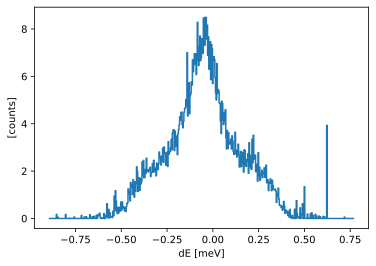

In [7]:
(event_object.hist(dE = 500)).plot()

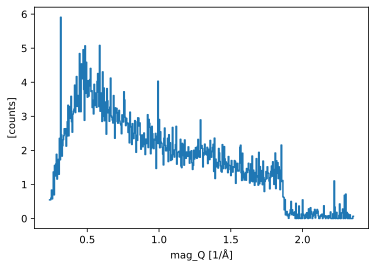

In [8]:
event_object.hist(mag_Q = 500).plot()

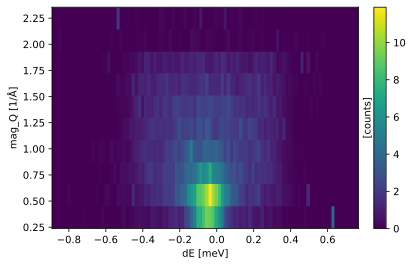

In [9]:
event_object.hist(mag_Q = 10, dE = 100).plot()

In [10]:
import plopp as pp
%matplotlib widget

In [11]:
pp.slicer(event_object.hist(mag_Q = 10, dE = 100), keep=['dE'], logc=True)
# pp.slicer(event_object, keep=['x', 'y], logc=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…